<center><h1>Основы глубокого обучение</h1></center>

## Домашнее задание: Обучение и визуализация xLSTM

### Цель задания

1. Обучить простую модель семейства xLSTM для обработки данных
2. Визуализировать веса внимания и интерпретировать их
3. Сделать выводы о том, как модель воспринимает данные и принимает решения?

In [ ]:
!pip install jupyterlab

In [ ]:
# Подавление предупреждений
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

# Импорт необходимых библиотек
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import polars as pl
import pandas as pd
import sklearn
import networkx as nx
import jupyterlab as jlab
import ipywidgets
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from torch import Tensor
from einops import rearrange
from typing import Tuple, Callable
from torch.autograd import Function

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D

## Архитектура xLSTM из семинара

In [ ]:
class CausalConv1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1, **kwargs):
        super(CausalConv1D, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, padding=self.padding, dilation=dilation, **kwargs)

    def forward(self, x):
        x = self.conv(x)
        return x[:, :, :-self.padding]

class BlockDiagonal(nn.Module):
    def __init__(self, in_features, out_features, num_blocks):
        super(BlockDiagonal, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.num_blocks = num_blocks

        assert out_features % num_blocks == 0

        block_out_features = out_features // num_blocks

        self.blocks = nn.ModuleList([
            nn.Linear(in_features, block_out_features)
            for _ in range(num_blocks)
        ])

    def forward(self, x):
        x = [block(x) for block in self.blocks]
        x = torch.cat(x, dim=-1)
        return x

class sLSTMBlock(nn.Module):
    def __init__(self, input_size, head_size, num_heads, proj_factor=4/3):
        super(sLSTMBlock, self).__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.proj_factor = proj_factor

        assert proj_factor > 0

        self.layer_norm = nn.LayerNorm(input_size)
        self.causal_conv = CausalConv1D(1, 1, 4)

        self.Wz = BlockDiagonal(input_size, self.hidden_size, num_heads)
        self.Wi = BlockDiagonal(input_size, self.hidden_size, num_heads)
        self.Wf = BlockDiagonal(input_size, self.hidden_size, num_heads)
        self.Wo = BlockDiagonal(input_size, self.hidden_size, num_heads)

        self.Rz = BlockDiagonal(self.hidden_size, self.hidden_size, num_heads)
        self.Ri = BlockDiagonal(self.hidden_size, self.hidden_size, num_heads)
        self.Rf = BlockDiagonal(self.hidden_size, self.hidden_size, num_heads)
        self.Ro = BlockDiagonal(self.hidden_size, self.hidden_size, num_heads)

        self.group_norm = nn.GroupNorm(num_heads, self.hidden_size)

        self.up_proj_left = nn.Linear(self.hidden_size, int(self.hidden_size * proj_factor))
        self.up_proj_right = nn.Linear(self.hidden_size, int(self.hidden_size * proj_factor))
        self.down_proj = nn.Linear(int(self.hidden_size * proj_factor), input_size)

    def forward(self, x, prev_state):
        assert x.size(-1) == self.input_size
        h_prev, c_prev, n_prev, m_prev = prev_state

        h_prev = h_prev.to(x.device)
        c_prev = c_prev.to(x.device)
        n_prev = n_prev.to(x.device)
        m_prev = m_prev.to(x.device)

        x_norm = self.layer_norm(x)
        x_conv = F.silu(self.causal_conv(x_norm.unsqueeze(1)).squeeze(1))

        z = torch.tanh(self.Wz(x_norm) + self.Rz(h_prev))
        o = torch.sigmoid(self.Wo(x_norm) + self.Ro(h_prev))
        i_tilde = self.Wi(x_conv) + self.Ri(h_prev)
        f_tilde = self.Wf(x_conv) + self.Rf(h_prev)

        # TODO !!!!
        m_t = torch.max(f_tilde + m_prev, i_tilde)
        i = torch.exp(i_tilde - m_t) # Всегда <= 1.0
        f = torch.exp(f_tilde + m_prev - m_t) # Всегда <= 1.0

        c_t = f * c_prev + i * z
        n_t = f * n_prev + i
        h_t = o * c_t / n_t

        output = h_t
        output_norm = self.group_norm(output)
        output_left = self.up_proj_left(output_norm)
        output_right = self.up_proj_right(output_norm)
        output_gated = F.gelu(output_right)
        output = output_left * output_gated
        output = self.down_proj(output)
        final_output = output + x

        return final_output, (h_t, c_t, n_t, m_t)

class sLSTM(nn.Module):
    # Add bias, dropout, bidirectional
    def __init__(self, input_size, head_size, num_heads, num_layers=1, batch_first=False, proj_factor=4/3):
        super(sLSTM, self).__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.batch_first = batch_first
        self.proj_factor_slstm = proj_factor

        self.layers = nn.ModuleList([sLSTMBlock(input_size, head_size, num_heads, proj_factor) for _ in range(num_layers)])

    def forward(self, x, state=None):
        assert x.ndim == 3
        if self.batch_first: x = x.transpose(0, 1)
        seq_len, batch_size, _ = x.size()

        if state is not None:
            state = torch.stack(list(state)).to(x.device)
            assert state.ndim == 4
            num_hidden, state_num_layers, state_batch_size, state_input_size = state.size()
            assert num_hidden == 4
            assert state_num_layers == self.num_layers
            assert state_batch_size == batch_size
            assert state_input_size == self.input_size
            state = state.transpose(0, 1)
        else:
            state = torch.zeros(self.num_layers, 4, batch_size, self.hidden_size, device=x.device)

        output = []
        for t in range(seq_len):
            x_t = x[t]
            for layer in range(self.num_layers):
                x_t, state_tuple = self.layers[layer](x_t, tuple(state[layer].clone()))
                state[layer] = torch.stack(list(state_tuple))
            output.append(x_t)

        output = torch.stack(output)
        if self.batch_first:
            output = output.transpose(0, 1)
        state = tuple(state.transpose(0, 1))
        return output, state

class mLSTMBlock(nn.Module):
    def __init__(self, input_size, head_size, num_heads, proj_factor=2):
        super(mLSTMBlock, self).__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.proj_factor = proj_factor

        assert proj_factor > 0

        self.layer_norm = nn.LayerNorm(input_size)
        self.up_proj_left = nn.Linear(input_size, int(input_size * proj_factor))
        self.up_proj_right = nn.Linear(input_size, self.hidden_size)
        self.down_proj = nn.Linear(self.hidden_size, input_size)

        self.causal_conv = CausalConv1D(1, 1, 4)
        self.skip_connection = nn.Linear(int(input_size * proj_factor), self.hidden_size)

        self.Wq = BlockDiagonal(int(input_size * proj_factor), self.hidden_size, num_heads)
        self.Wk = BlockDiagonal(int(input_size * proj_factor), self.hidden_size, num_heads)
        self.Wv = BlockDiagonal(int(input_size * proj_factor), self.hidden_size, num_heads)
        self.Wi = nn.Linear(int(input_size * proj_factor), self.hidden_size)
        self.Wf = nn.Linear(int(input_size * proj_factor), self.hidden_size)
        self.Wo = nn.Linear(int(input_size * proj_factor), self.hidden_size)

        self.group_norm = nn.GroupNorm(num_heads, self.hidden_size)

    def forward(self, x, prev_state):
        h_prev, c_prev, n_prev, m_prev = prev_state

        h_prev = h_prev.to(x.device)
        c_prev = c_prev.to(x.device)
        n_prev = n_prev.to(x.device)
        m_prev = m_prev.to(x.device)

        assert x.size(-1) == self.input_size
        x_norm = self.layer_norm(x)
        x_up_left = self.up_proj_left(x_norm)
        x_up_right = self.up_proj_right(x_norm)

        x_conv = F.silu(self.causal_conv(x_up_left.unsqueeze(1)).squeeze(1))
        x_skip = self.skip_connection(x_conv)

        q = self.Wq(x_conv)
        k = self.Wk(x_conv) / (self.head_size ** 0.5)
        v = self.Wv(x_up_left)

        i_tilde = self.Wi(x_conv)
        f_tilde = self.Wf(x_conv)
        o = torch.sigmoid(self.Wo(x_up_left))

        m_t = torch.max(f_tilde + m_prev, i_tilde)
        i = torch.exp(i_tilde - m_t)
        f = torch.exp(f_tilde + m_prev - m_t)

        c_t = f * c_prev + i * (v * k) # v @ k.T
        n_t = f * n_prev + i * k
        h_t = o * (c_t * q) / torch.max(torch.abs(n_t.T @ q), 1)[0] # o * (c @ q) / max{|n.T @ q|, 1}

        output = h_t
        output_norm = self.group_norm(output)
        output = output_norm + x_skip
        output = output * F.silu(x_up_right)
        output = self.down_proj(output)
        final_output = output + x

        return final_output, (h_t, c_t, n_t, m_t)

class mLSTM(nn.Module):
    # Add bias, dropout, bidirectional
    def __init__(self, input_size, head_size, num_heads, num_layers=1, batch_first=False, proj_factor=2):
        super(mLSTM, self).__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.batch_first = batch_first
        self.proj_factor_slstm = proj_factor

        self.layers = nn.ModuleList([mLSTMBlock(input_size, head_size, num_heads, proj_factor) for _ in range(num_layers)])

    def forward(self, x, state=None):
        assert x.ndim == 3
        if self.batch_first: x = x.transpose(0, 1)
        seq_len, batch_size, _ = x.size()

        if state is not None:
            state = torch.stack(list(state)).to(x.device)
            assert state.ndim == 4
            num_hidden, state_num_layers, state_batch_size, state_input_size = state.size()
            assert num_hidden == 4
            assert state_num_layers == self.num_layers
            assert state_batch_size == batch_size
            assert state_input_size == self.input_size
            state = state.transpose(0, 1)
        else:
            state = torch.zeros(self.num_layers, 4, batch_size, self.hidden_size, device=x.device)

        output = []
        for t in range(seq_len):
            x_t = x[t]
            for layer in range(self.num_layers):
                x_t, state_tuple = self.layers[layer](x_t, tuple(state[layer].clone()))
                state[layer] = torch.stack(list(state_tuple))
            output.append(x_t)

        output = torch.stack(output)
        if self.batch_first:
            output = output.transpose(0, 1)
        state = tuple(state.transpose(0, 1))
        return output, state

class xLSTM(nn.Module):
    # Add bias, dropout, bidirectional
    def __init__(self, input_size, head_size, num_heads, layers, batch_first=False, proj_factor_slstm=4/3, proj_factor_mlstm=2):
        super(xLSTM, self).__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.layers = layers
        self.num_layers = len(layers)
        self.batch_first = batch_first
        self.proj_factor_slstm = proj_factor_slstm
        self.proj_factor_mlstm = proj_factor_mlstm

        self.layers = nn.ModuleList()
        for layer_type in layers:
            if layer_type == 's':
                layer = sLSTMBlock(input_size, head_size, num_heads, proj_factor_slstm)
            elif layer_type == 'm':
                layer = mLSTMBlock(input_size, head_size, num_heads, proj_factor_mlstm)
            else:
                raise ValueError(f"Invalid layer type")
            self.layers.append(layer)

    def forward(self, x, state=None):
        assert x.ndim == 3
        if self.batch_first: x = x.transpose(0, 1)
        seq_len, batch_size, _ = x.size()

        if state is not None:
            state = torch.stack(list(state)).to(x.device)
            assert state.ndim == 4
            num_hidden, state_num_layers, state_batch_size, state_input_size = state.size()
            assert num_hidden == 4
            assert state_num_layers == self.num_layers
            assert state_batch_size == batch_size
            assert state_input_size == self.input_size
            state = state.transpose(0, 1)
        else:
            state = torch.zeros(self.num_layers, 4, batch_size, self.hidden_size, device=x.device)

        output = []
        for t in range(seq_len):
            x_t = x[t]
            for layer in range(self.num_layers):
                x_t, state_tuple = self.layers[layer](x_t, tuple(state[layer].clone()))
                state[layer] = torch.stack(list(state_tuple))
            output.append(x_t)

        output = torch.stack(output)
        if self.batch_first:
            output = output.transpose(0, 1)
        state = tuple(state.transpose(0, 1))
        return output, state

**Установка emotion Dataset**



In [5]:
from datasets import load_dataset
from collections import Counter

dataset = load_dataset("emotion")

print("Train size:", len(dataset['train']))
print("Test size:", len(dataset['test']))

print("Карта классов:", dataset['train'].features['label'].names)
print("Train label distribution:", Counter([ex['label'] for ex in dataset['train']]))


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train size: 16000
Test size: 2000
Карта классов: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Train label distribution: Counter({1: 5362, 0: 4666, 3: 2159, 4: 1937, 2: 1304, 5: 572})


### Очистка текста и приведение к нижнему регистру, убраны HTML-теги и лишние пробелы.


In [6]:
import re

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def preprocess_function(examples):
    examples['text'] = [preprocess_text(txt) for txt in examples['text']]
    return examples

dataset = dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

### Создание словаря и падинг

In [7]:
max_vocab_size = 11_000
from collections import Counter

counter = Counter()
for ex in dataset['train']:
    counter.update(ex['text'].split())

vocab = {'<PAD>': 0, '<UNK>': 1}
for word, _ in counter.most_common(max_vocab_size-2):
    vocab[word] = len(vocab)
print("Vocab size:", len(vocab))

def tokenize_and_pad(text, vocab, max_length=32):
    tokens = [vocab.get(w, vocab['<UNK>']) for w in text.split()]
    return tokens[:max_length] + [vocab['<PAD>']]*(max_length - len(tokens))


Vocab size: 11000


### Создание датасета

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader

class ClassificationDataset(Dataset):
    def __init__(self, hf_dataset, vocab, max_length=32):
        self.data = hf_dataset
        self.vocab = vocab
        self.max_length = max_length
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        ex = self.data[idx]
        input_ids = torch.tensor(tokenize_and_pad(ex['text'], self.vocab, self.max_length), dtype=torch.long)
        label = torch.tensor(ex['label'], dtype=torch.long)
        return {'input_ids': input_ids, 'label': label}

train_dataset = ClassificationDataset(dataset['train'], vocab)
test_dataset = ClassificationDataset(dataset['test'], vocab)


In [9]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size)


### Создание класса модели с xLSTM

In [10]:
import torch.nn as nn

class XLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes,
                 head_size=40, num_heads=2, layers=['s', 'm'], batch_first=True,
                 proj_factor_slstm=4/3, proj_factor_mlstm=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.xlstm = xLSTM(
            input_size=embedding_dim,
            head_size=head_size,
            num_heads=num_heads,
            layers=layers,
            batch_first=batch_first,
            proj_factor_slstm=proj_factor_slstm,
            proj_factor_mlstm=proj_factor_mlstm
        )
        self.head = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, 48),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(48, num_classes)
        )
    def forward(self, input_ids):
        emb = self.embedding(input_ids)
        out, _ = self.xlstm(emb)
        return self.head(out[:, -1, :])


### Инициализация модели

In [11]:
import torch.optim as optim
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = XLSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=40,
    num_classes=6
).to(device)
optimizer = optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Количество обучаемых параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Количество обучаемых параметров: 558484


### Обучение модели

In [80]:
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_tot, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)
            logits = model(input_ids)
            loss = criterion(logits, labels)
            loss_tot += loss.item() * input_ids.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total += input_ids.size(0)
    return loss_tot / total, correct / total

for epoch in range(12):
    model.train()
    loss_tot, correct, total = 0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        labels = batch['label'].to(device)
        logits = model(input_ids)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        loss_tot += loss.item() * input_ids.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += input_ids.size(0)
        pbar.set_postfix({'train_loss': f'{loss_tot/total:.4f}', 'train_acc': f'{correct/total:.3f}'})

    train_loss = loss_tot / total
    train_acc = correct / total

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"\nEpoch {epoch+1} summary: Train loss: {train_loss:.4f}  acc: {train_acc:.3f} "
          f"| Test loss: {test_loss:.4f}  acc: {test_acc:.3f}")
    print("-----")


Epoch 1: 100%|██████████| 250/250 [01:24<00:00,  2.97it/s, train_loss=1.5953, train_acc=0.329]



Epoch 1 summary: Train loss: 1.5953  acc: 0.329 | Test loss: 1.5480  acc: 0.363
-----


Epoch 2: 100%|██████████| 250/250 [01:23<00:00,  3.00it/s, train_loss=1.5511, train_acc=0.369]



Epoch 2 summary: Train loss: 1.5511  acc: 0.369 | Test loss: 1.5081  acc: 0.395
-----


Epoch 3: 100%|██████████| 250/250 [01:22<00:00,  3.03it/s, train_loss=1.4799, train_acc=0.415]


...


Epoch 10 summary: Train loss: 0.7259  acc: 0.747 | Test loss: 1.1830  acc: 0.586
-----


Epoch 11: 100%|██████████| 250/250 [01:21<00:00,  3.05it/s, train_loss=0.6408, train_acc=0.782]



Epoch 11 summary: Train loss: 0.6408  acc: 0.782 | Test loss: 1.1943  acc: 0.602
-----


Epoch 12: 100%|██████████| 250/250 [01:21<00:00,  3.06it/s, train_loss=0.5592, train_acc=0.812]



Epoch 12 summary: Train loss: 0.5592  acc: 0.812 | Test loss: 1.2201  acc: 0.600
-----


### В forward mLSTMBlock добавлено сохранение attention для дальнейшей визуализации.


In [12]:
import types

def mLSTMBlock_forward_with_attention(self, x, prev_state):
    h_prev, c_prev, n_prev, m_prev = prev_state
    h_prev = h_prev.to(x.device); c_prev = c_prev.to(x.device)
    n_prev = n_prev.to(x.device); m_prev = m_prev.to(x.device)
    x_norm = self.layer_norm(x)
    x_up_left = self.up_proj_left(x_norm)
    x_up_right = self.up_proj_right(x_norm)
    x_conv = F.silu(self.causal_conv(x_up_left.unsqueeze(1)).squeeze(1))
    x_skip = self.skip_connection(x_conv)
    q = self.Wq(x_conv)
    k = self.Wk(x_conv) / (self.head_size ** 0.5)
    v = self.Wv(x_up_left)
    # веса внимания
    if not hasattr(self, "attention_log"):
        self.attention_log = []
    score = (q * k)
    self.attention_log.append(score.detach().cpu())

    i_tilde = self.Wi(x_conv)
    f_tilde = self.Wf(x_conv)
    o = torch.sigmoid(self.Wo(x_up_left))
    m_t = torch.max(f_tilde + m_prev, i_tilde)
    i = torch.exp(i_tilde - m_t)
    f = torch.exp(f_tilde + m_prev - m_t)
    c_t = f * c_prev + i * (v * k)
    n_t = f * n_prev + i * k
    h_t = o * (c_t * q) / torch.max(torch.abs(n_t.T @ q), 1)[0]
    output = h_t
    output_norm = self.group_norm(output)
    output = output_norm + x_skip
    output = output * F.silu(x_up_right)
    output = self.down_proj(output)
    final_output = output + x
    return final_output, (h_t, c_t, n_t, m_t)

for module in model.modules():
    if isinstance(module, mLSTMBlock):
        module.forward = types.MethodType(mLSTMBlock_forward_with_attention, module)
        break


### Визуализация

In [13]:
model.eval()
example = next(iter(test_loader))
input_ids = example['input_ids'][:1].to(device)
with torch.no_grad():
    _ = model(input_ids)


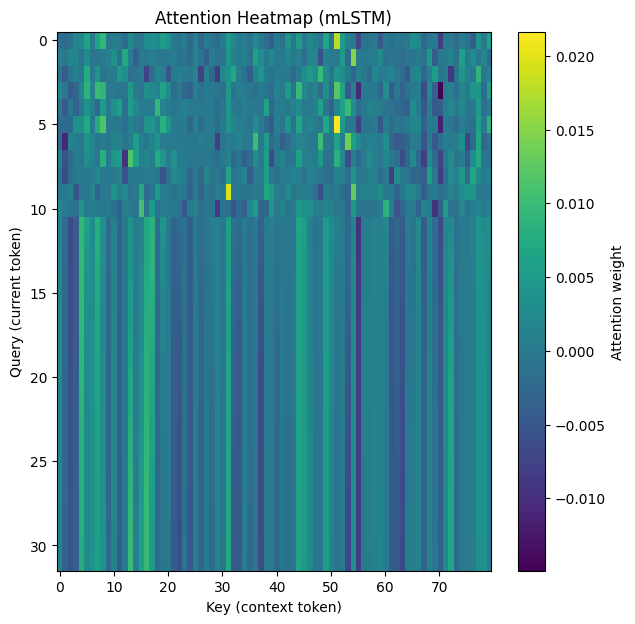

In [85]:
import matplotlib.pyplot as plt

for module in model.modules():
    if hasattr(module, 'last_attention'):
        attn = module.last_attention.squeeze().numpy()
        break


plt.figure(figsize=(7,7))
plt.imshow(attn, cmap='viridis', aspect='auto')
plt.colorbar(label='Attention weight')
plt.xlabel('Key (context token)')
plt.ylabel('Query (current token)')
plt.title('Attention Heatmap (mLSTM)')
plt.show()



## 1. Визуализация весов внимания и их интерпретация
Оси:

X — позиция токена-контекста, на который может быть направлено внимание

Y — токен, который спрашивае, на что ему смотреть

Верхние строки (начало последовательности) показывают много вариативности: внимание распределено между разными токенами.

Нижняя часть графика (часто длинные полосы) может быть связана с тем, что многие позиции — это <PAD> токены

В отдельных местах видны яркие прямоугольники, вероятно, это ключевые слова или эмоциональные маркеры, на которых attention собирается.

2. Как модель воспринимает данные и принимает решения

Кроме чтения токенов последовательно, модель ищет в каждом опорные точки и анализирует их взаимные связи. Ключевые/эмоциональные слова будут притягивать к себе внимание, если они важны для определения класса (эмоции, тональности).

sLSTM фильтрует локальные признаки и токены, снижая шум и ненужную информацию. mLSTM строит attention-map, связывая удалённые друг от друга элементы. По последнему вектору, собравшему в себя всю обработку, определяем класс учитывая весь смысл фразы.





